In [1]:
import time
import h5py
import numpy as np
import tifffile
import tomopy
import matplotlib.pyplot as plt

PROJ_PATH  = '/Users/levihancock/Documents/Work/Code/TomoMono/alignedProjections/APSbeamtime_Oct25/cfg59_ds4x_aligned_20260505-121404.tif'
ANGLE_PATH = "/Users/levihancock/Library/CloudStorage/Box-Box/BYU_CXI_Research_Team/ProjectFolders/IFE-STAR/IFE-Ptycho-Tomo/APS_2ID_GUP1013052_August_2025/levi_tomoReconstructions/tomo_data_run_final_2.hdf5"

N_ITER     = 30   # iterations for iterative algorithms

projs = tifffile.imread(PROJ_PATH).astype(np.float32)  # (n_angles, ny, nx)
with h5py.File(ANGLE_PATH) as f:
    angles = f['angles'][...] * np.pi / 180

print(f'Projections : {projs.shape}  [{projs.min():.3f}, {projs.max():.3f}]')
print(f'Angles      : {len(angles)}  [{np.degrees(angles.min()):.1f}°, {np.degrees(angles.max()):.1f}°]')

center = tomopy.find_center_vo(projs)
print(f'Rotation center: {center:.2f} px')

Projections : (558, 146, 327)  [-6.368, 0.541]
Angles      : 558  [-72.0°, 58.8°]
Rotation center: 163.25 px


  Running gridrec         Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


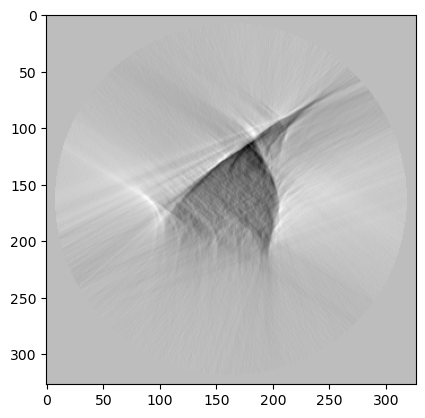

     5.7 s   shape=(146, 327, 327)
  Running fbp             

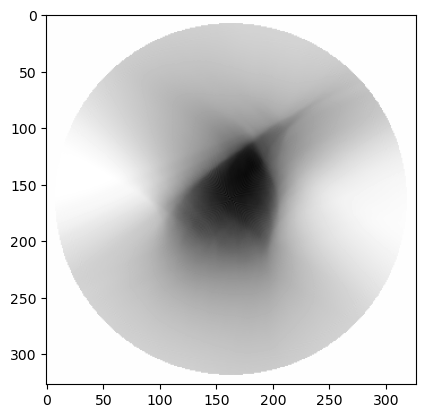

    31.0 s   shape=(146, 327, 327)
  Running art             

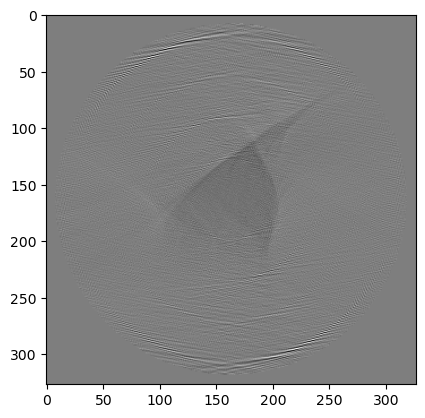

   509.2 s   shape=(146, 327, 327)
  Running bart            

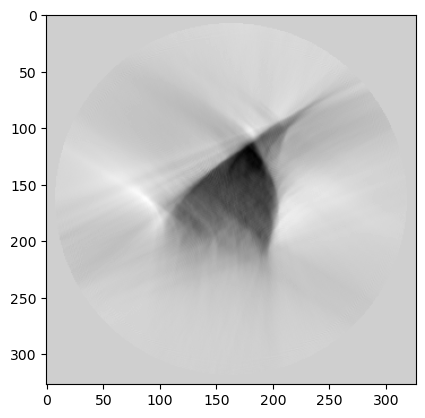

  9293.4 s   shape=(146, 327, 327)
  Running sirt            

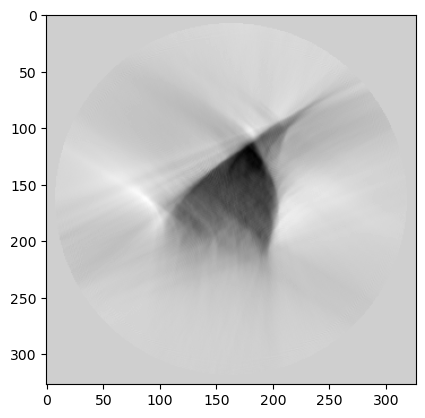

  35925.9 s   shape=(146, 327, 327)
  Running mlem            

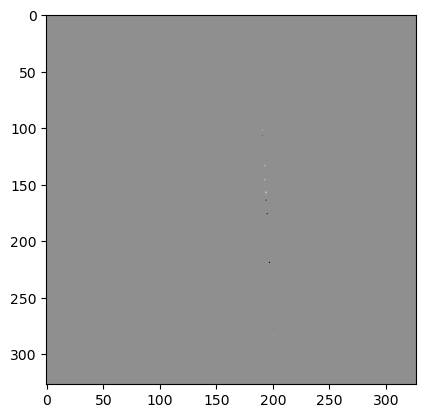

  1430.2 s   shape=(146, 327, 327)
  Running osem            

In [ ]:
# All CPU-compatible tomopy algorithms.
# Iterative algorithms use N_ITER iterations.
ALGORITHMS = [
    ('gridrec',       {}),
    ('fbp',           {}),
    ('art',           {'num_iter': N_ITER}),
    ('bart',          {'num_iter': N_ITER}),
    ('sirt',          {'num_iter': N_ITER}),
    ('mlem',          {'num_iter': N_ITER}),
    ('osem',          {'num_iter': N_ITER}),
    ('ospml_hybrid',  {'num_iter': N_ITER}),
    ('ospml_quad',    {'num_iter': N_ITER}),
    ('pml_hybrid',    {'num_iter': N_ITER}),
    ('pml_quad',      {'num_iter': N_ITER}),
    ('tv',            {'num_iter': N_ITER}),
    ('grad',          {'num_iter': N_ITER}),
]

results = {}   # name → {'recon': ndarray, 'time_s': float}

for name, kwargs in ALGORITHMS:
    print(f'  Running {name:<16}', end='', flush=True)
    t0 = time.time()
    try:
        recon = tomopy.recon(projs, angles, center=center,
                             algorithm=name, sinogram_order=False, **kwargs)
        recon = tomopy.circ_mask(recon, axis=0, ratio=0.95)
        plt.imshow(recon[recon.shape[0]//2], cmap='gray')
        plt.show()
        elapsed = time.time() - t0
        results[name] = {'recon': recon, 'time_s': elapsed}
        print(f'  {elapsed:6.1f} s   shape={recon.shape}')
    except Exception as e:
        elapsed = time.time() - t0
        results[name] = {'recon': None, 'time_s': elapsed, 'error': str(e)}
        print(f'  FAILED: {e}')

print('\nDone.')

In [ ]:
ok = [(name, d) for name, d in results.items() if d['recon'] is not None]
n  = len(ok)

fig, axes = plt.subplots(n, 3, figsize=(12, 3.2 * n))
if n == 1:
    axes = axes[np.newaxis, :]

PLANE_LABELS = ['XY  (central Z)', 'XZ  (central Y)', 'YZ  (central X)']
CMAPS        = ['gray', 'gray', 'gray']

for row, (name, d) in enumerate(ok):
    vol = d['recon']                                # (nz, ny, nx)
    nz, ny, nx = vol.shape
    slices = [
        vol[nz // 2, :, :],
        vol[:, ny // 2, :],
        vol[:, :, nx // 2],
    ]
    for col, (slc, label) in enumerate(zip(slices, PLANE_LABELS)):
        lo, hi = np.percentile(slc, [2, 98])
        ax = axes[row, col]
        ax.imshow(slc, cmap='gray', vmin=lo, vmax=hi, aspect='auto')
        ax.axis('off')
        if col == 0:
            ax.set_title(f'{name}  ({d["time_s"]:.1f} s)', fontsize=9, loc='left')
        else:
            ax.set_title(label, fontsize=7, color='gray')

fig.suptitle(f'Tomopy algorithm comparison  |  {N_ITER} iterations (iterative)  |  ds=4x', fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
print(f'{'Algorithm':<20} {'Time (s)':>10}  Status')
print('-' * 42)
for name, d in results.items():
    status = 'ok' if d['recon'] is not None else f"FAILED: {d.get('error','')[:40]}"
    print(f'{name:<20} {d["time_s"]:>10.1f}  {status}')